# ThaiChar72 — Stress evaluation

Companion to `reports/stress/summary.md` and `reports/02-EXPERIMENTS.md` §N. The report states the
conclusions; this notebook is for **checking them yourself** — every section pairs its table with a
drill-down that shows the actual images and what the model predicted.

**Run it**

```bash
cd ~/work/thaichar72
uv pip install jupyterlab ipykernel          # not in the locked deps
uv run --no-sync python -m ipykernel install --user --name thaichar --display-name "thaichar"
uv run --no-sync jupyter lab notebooks/ThaiChar72_StressEval.ipynb
```

Pick the **thaichar** kernel and Run All. Use `uv pip install`, never `uv sync` or a bare `uv run`
(`tasks/HANDOFF-2026-09-22.md` §1.1), and run it from `~/work/thaichar72` — running `uv` against the
`/mnt/d` copy from WSL deletes that copy's venv.

Regenerate the underlying numbers any time with:

```bash
uv run --no-sync python scripts/stress_suite.py --models all --families A B C
```

**The three families are scored differently on purpose**

| family | is there a correct answer? | what is reported |
|---|---|---|
| **A** degraded (blur, pixelate, rotation, unseen fonts…) | yes, unchanged | top-1 retention vs severity |
| **B** invalid (two glyphs touching, half a glyph, scribbles…) | **no** | confidence and separability — **never accuracy** |
| **C** identity-changing (mirror, upside down, 90°) | maybe a *different* class | a mapping table |

Reporting accuracy on a picture of two glued characters would be meaningless, because no label is
correct. What family B measures instead is whether the model signals that it is out of its depth.


## 1. Setup and stress artefacts

Loads `reports/stress/results.csv` and `flip_map.csv`, and prints the clean baseline every retention number is divided by.

In [1]:
# Setup: paths, Thai font, and the stress-suite artefacts.
%matplotlib inline
import os, sys, json
from pathlib import Path

PROJECT_DIR = Path.cwd()
while not (PROJECT_DIR / "src" / "thaichar").exists() and PROJECT_DIR != PROJECT_DIR.parent:
    PROJECT_DIR = PROJECT_DIR.parent
os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR / "src"))
sys.path.insert(0, str(PROJECT_DIR / "scripts"))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib import font_manager

fp = PROJECT_DIR / "assets" / "fonts" / "Sarabun-Regular.ttf"
if fp.exists():
    font_manager.fontManager.addfont(str(fp))
    plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(fp)).get_name()
plt.rcParams["axes.unicode_minus"] = False

STRESS = PROJECT_DIR / "reports" / "stress"
print("project :", PROJECT_DIR)
print("stress  :", STRESS, "(exists:", STRESS.exists(), ")")

if not (STRESS / "results.csv").exists():
    print()
    print("No results yet. Generate them with:")
    print("   uv run --no-sync python scripts/stress_suite.py --models all --families A B C")
else:
    res = pd.read_csv(STRESS / "results.csv")
    flip = pd.read_csv(STRESS / "flip_map.csv") if (STRESS / "flip_map.csv").exists() else pd.DataFrame()
    clean = res[res.family == "clean"].set_index("model")["top1"]
    print()
    print("rows:", len(res), " models:", res.model.nunique(), " conditions:", res.condition.nunique())
    print()
    print("clean baseline (493 held-out val glyphs, deployed preprocessing + polarity-both):")
    for m, v in clean.items():
        print(f"   {m:<34} {v:.4f}")

project : /home/metaverse/work/thaichar72
stress  : /home/metaverse/work/thaichar72/reports/stress (exists: True )

rows: 220  models: 5  conditions: 24

clean baseline (493 held-out val glyphs, deployed preprocessing + polarity-both):
   thaichar72_r18_64_gen              0.9858
   thaichar72_r18_64_gen_v3labels     0.9817
   thaichar72_resnet18_64             0.9776
   thaichar72_resnet18_64_v1labels    0.9695
   thaichar72_mnv3small_64_small      0.9634


## 2. Harness sanity check — and the bug it caught

The suite's acceptance criterion is that its clean baseline reproduces the model's known validation top-1. It did not, and that is how a **real deployment bug** surfaced: `infer.preprocess_image` scored **0.9695 against the dataset transform's 0.9898** on the same images — wrong on 10, right on none. `_reframe` padded tight crops with the *median* of the four corners, which on a glyph whose strokes touch the corners is ink-coloured; Otsu then read that pad as background and inverted the image. It also silently defeated `--polarity both`, since inverting the input moved the bad guess rather than fixing it. Using the **lightest** corner restores 0.9898 exactly. This cell re-measures both paths so the fix stays verified.

In [2]:
# Harness sanity check, recomputed live.
#
# The suite's own acceptance criterion is that the clean baseline reproduces the model's known
# validation top-1. Running it the first time is what exposed a real deployment bug: the inference
# path (infer.preprocess_image) scored 2 pt BELOW the training-time dataset transform on the very
# same images, because _reframe padded tight crops with an ink-coloured background and Otsu then
# inverted them. This cell re-measures both paths so the fix stays verified.
from stress_suite import base_sample
from thaichar.infer import load_checkpoint, preprocess_image
from thaichar.data import ThaiGlyphDataset

CKPT = "weights/thaichar72_r18_64_gen.pt"
device = "cuda" if torch.cuda.is_available() else "cpu"
model, cfg = load_checkpoint(CKPT, device=device)
model.eval()

imgs, y = base_sample(8, 0)
keep, xs, gs = [], [], []
for i, a in enumerate(imgs):
    try:
        x, g = preprocess_image(a, cfg)
    except Exception:
        continue
    keep.append(i); xs.append(x); gs.append(g)
keep = np.array(keep); yk = y[keep]
with torch.no_grad():
    p_dep = model(torch.cat(xs).to(device), torch.cat(gs).to(device)).argmax(1).cpu().numpy()

class _Shim:
    def __init__(s, L): s.L = L; s.paths = [str(i) for i in range(len(L))]
    def __len__(s): return len(s.L)
    def __getitem__(s, i): return s.L[i]

sub = [imgs[i] for i in keep]
df = pd.DataFrame({"path": [str(i) for i in range(len(sub))], "label": yk,
                   "height": [a.shape[0] for a in sub], "width": [a.shape[1] for a in sub],
                   "ink_frac": [float((a < 128).mean()) for a in sub]})
ds = ThaiGlyphDataset(df, _Shim(sub), size=cfg["img_size"], channel_mode=cfg["channel_mode"],
                      transform=None, margin=cfg["margin"])
with torch.no_grad():
    p_ds = model(torch.stack([ds[i][0] for i in range(len(ds))]).to(device),
                 torch.stack([ds[i][1] for i in range(len(ds))]).to(device)).argmax(1).cpu().numpy()

print(f"images compared                       : {len(yk)}")
print(f"training-time dataset transform       : {np.mean(p_ds == yk):.4f}")
print(f"deployed preprocess_image (single)    : {np.mean(p_dep == yk):.4f}")
d = p_dep != p_ds
print(f"disagreements                         : {d.sum()}")
print(f"   dataset right / deployed wrong     : {((p_ds == yk) & d).sum()}")
print(f"   deployed right / dataset wrong     : {((p_dep == yk) & d).sum()}")
print()
print("With the _reframe fix these should be within a few images of each other.")
print("Before the fix: 0.9695 vs 0.9898, wrong on 10 and right on none.")

/home/metaverse/work/thaichar72/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


images compared                       : 492
training-time dataset transform       : 0.9898
deployed preprocess_image (single)    : 0.9898
disagreements                         : 0
   dataset right / deployed wrong     : 0
   deployed right / dataset wrong     : 0

With the _reframe fix these should be within a few images of each other.
Before the fix: 0.9695 vs 0.9898, wrong on 10 and right on none.


## 3. Family A — degraded input, the answer still exists

In [3]:
# Family A - degraded input, the correct answer still exists.
# Retention = top-1 under the corruption divided by that model's own clean top-1.
a = res[res.family == "A"].copy()
a["retention"] = [r.top1 / clean[r.model] for _, r in a.iterrows()]

piv = a.pivot_table(index=["condition", "severity"], columns="model", values="retention")
piv.columns = [c.replace("thaichar72_", "") for c in piv.columns]
print("retention by corruption and severity (1.00 = no loss)")
display(piv.round(3).style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1, axis=None))

retention by corruption and severity (1.00 = no loss)


### 3b. Drill-down: see the corruption and the mistakes it causes

`show_corruption("pixelate", 0.25)` · `show_corruption("rotate_hard", 30)` · `show_corruption("stroke_extreme", -4)` · `show_corruption("unseen_font")`

pixelate severity=0.25   top-1 0.4167   mean confidence 0.732   rejected by preprocessing 1


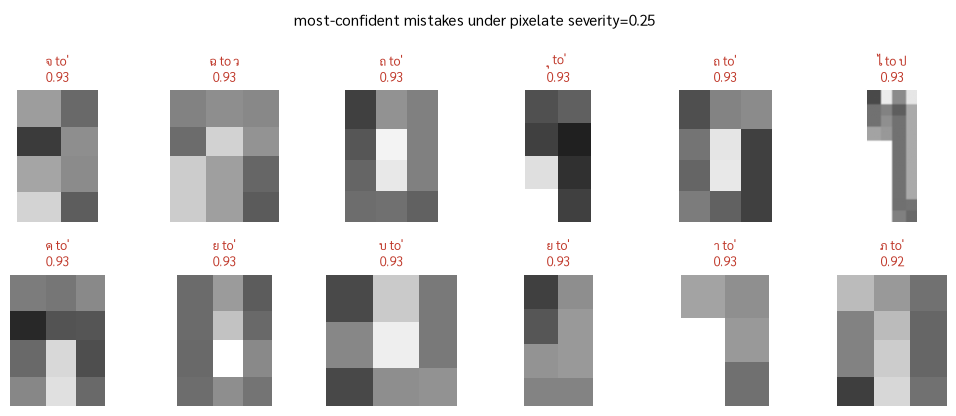

In [4]:
# See what a corruption actually does, and what the model says about it.
#   show_corruption("pixelate", 0.25)      show_corruption("rotate_hard", 30)
#   show_corruption("stroke_extreme", -4)  show_corruption("unseen_font")
import stress_suite as SS
from thaichar.classes import CLASS_CODES, code_to_char

_base_imgs, _base_y = base_sample(8, 0)

def show_corruption(name, severity=None, n=12, ckpt=None):
    if ckpt is None:
        m, c = model, cfg
    else:
        m, c = load_checkpoint(ckpt, device=device); m.eval()
    if name == "unseen_font":
        imgs, ys, nf = SS.render_unseen_font(1, 0)
        title = f"unseen_font ({nf} typefaces the stage-1 render never used)"
    else:
        fn, sevs = SS.FAMILY_A[name]
        if severity is None:
            severity = sevs[-1]
        imgs = [fn(x, severity) for x in _base_imgs]
        ys = _base_y
        title = f"{name} severity={severity}"
    batches, keep = SS.to_batch(imgs, c, device)
    if len(keep) == 0:
        print("every image was rejected by preprocessing"); return
    pr = SS.probs_for(m, batches)
    pred, conf, yk = pr.argmax(1), pr.max(1), np.array(ys)[keep]
    acc = float((pred == yk).mean())
    print(f"{title}   top-1 {acc:.4f}   mean confidence {conf.mean():.3f}   "
          f"rejected by preprocessing {len(imgs) - len(keep)}")
    order = np.argsort(conf)[::-1]
    wrong = [i for i in order if pred[i] != yk[i]][:n]
    if not wrong:
        print("no errors at this severity"); return
    cols = min(n, 6); rows = int(np.ceil(len(wrong) / cols))
    fig, ax = plt.subplots(rows, cols, figsize=(1.7 * cols, 2.1 * rows), squeeze=False)
    for axx in np.ravel(ax): axx.axis("off")
    for axx, i in zip(np.ravel(ax), wrong):
        axx.imshow(imgs[keep[i]], cmap="gray", vmin=0, vmax=255)
        axx.set_title(f"{code_to_char(CLASS_CODES[yk[i]])} to "
                      f"{code_to_char(CLASS_CODES[pred[i]])}" + chr(10) + f"{conf[i]:.2f}",
                      fontsize=9, color="#c0392b")
    fig.suptitle("most-confident mistakes under " + title, fontsize=11)
    fig.tight_layout(); plt.show()

show_corruption("pixelate", 0.25)

## 4. Family B — invalid input, no correct answer exists

Nothing here reports accuracy. `separability AUROC` answers the only actionable question: can a confidence threshold alone tell this junk from clean input? **≥ 0.8 yes; ≤ 0.6 no, and the input pipeline would have to be fixed instead** (e.g. splitting touching glyphs before classifying).

In [5]:
# Family B - invalid input. There is NO correct answer, so nothing here reports accuracy.
# separability AUROC = can a confidence threshold alone tell this junk from clean input?
#   >= 0.8 yes, a threshold works.   <= 0.6 no, the input pipeline has to be fixed instead.
b = res[res.family == "B"].copy()
b["model"] = b.model.str.replace("thaichar72_", "", regex=False)

print("separability AUROC (higher = easier to filter out by confidence)")
display(b.pivot_table(index="condition", columns="model", values="separability_auroc")
         .round(3).style.background_gradient(cmap="RdYlGn", vmin=0.5, vmax=1.0, axis=None))

print()
print("fraction of junk that still gets a >= 0.9 confidence prediction (lower = safer)")
display(b.pivot_table(index="condition", columns="model", values="confident_wrong@0.9")
         .round(3).style.background_gradient(cmap="RdYlGn_r", vmin=0, vmax=0.25, axis=None))

worst = b.loc[b.separability_auroc.idxmin()]
print()
print(f"weakest separation: {worst.condition} at AUROC {worst.separability_auroc:.3f}")
print("A splitter for touching glyphs is only worth building if some family sits at or below 0.6.")

separability AUROC (higher = easier to filter out by confidence)


model,mnv3small_64_small,r18_64_gen,r18_64_gen_v3labels,resnet18_64,resnet18_64_v1labels
condition,,,,,
blobs,0.889000,0.966000,0.925000,0.975000,0.957000
half_50,0.905000,0.874000,0.868000,0.911000,0.888000
half_70,0.884000,0.879000,0.899000,0.912000,0.885000
latin_digits,0.947000,0.943000,0.930000,0.962000,0.962000
near_empty,0.974000,0.998000,0.998000,0.973000,0.984000
overlap_2_25,0.921000,0.924000,0.921000,0.912000,0.909000
overlap_2_50,0.851000,0.858000,0.849000,0.862000,0.844000
strokes,0.982000,0.997000,0.995000,0.996000,0.996000
touching_2,0.954000,0.960000,0.945000,0.962000,0.937000



fraction of junk that still gets a >= 0.9 confidence prediction (lower = safer)


model,mnv3small_64_small,r18_64_gen,r18_64_gen_v3labels,resnet18_64,resnet18_64_v1labels
condition,,,,,
blobs,0.117000,0.030000,0.087000,0.013000,0.050000
half_50,0.108000,0.158000,0.155000,0.111000,0.155000
half_70,0.124000,0.164000,0.114000,0.094000,0.147000
latin_digits,0.044000,0.067000,0.077000,0.044000,0.044000
near_empty,0.000000,0.000000,0.000000,0.003000,0.010000
overlap_2_25,0.083000,0.083000,0.087000,0.110000,0.113000
overlap_2_50,0.180000,0.190000,0.187000,0.163000,0.220000
strokes,0.020000,0.003000,0.003000,0.000000,0.000000
touching_2,0.043000,0.047000,0.070000,0.043000,0.080000



weakest separation: overlap_2_50 at AUROC 0.844
A splitter for touching glyphs is only worth building if some family sits at or below 0.6.


### 4b. Drill-down: what the model confidently calls junk

`show_junk("overlap_2_50")` · `show_junk("touching_2")` · `show_junk("half_50")` · `show_junk("strokes")` · `show_junk("latin_digits")`

overlap_2_50: 200 usable of 200   mean confidence 0.646   share at or above 0.9: 16.0%


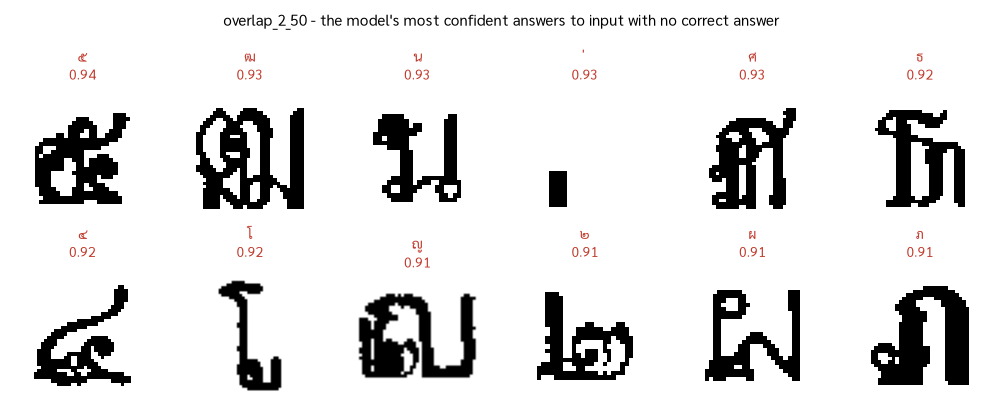

In [6]:
# Look at the junk itself, and at what the model confidently calls it.
#   show_junk("overlap_2_50")   show_junk("touching_2")   show_junk("half_50")
#   show_junk("strokes")        show_junk("blobs")        show_junk("latin_digits")
_rng = np.random.default_rng(0)

def _build_junk(kind, n=200):
    r = np.random.default_rng(0)
    if kind == "touching_2":   return SS.b_pairs(_base_imgs, r, n, 0.0)
    if kind == "overlap_2_25": return SS.b_pairs(_base_imgs, r, n, 0.25)
    if kind == "overlap_2_50": return SS.b_pairs(_base_imgs, r, n, 0.50)
    if kind == "triple":       return SS.b_triples(_base_imgs, r, n)
    if kind == "half_50":      return SS.b_half(_base_imgs, r, n, 0.50)
    if kind == "half_70":      return SS.b_half(_base_imgs, r, n, 0.70)
    if kind == "strokes":      return SS.b_strokes(r, n)
    if kind == "blobs":        return SS.b_blobs(r, n)
    if kind == "latin_digits": return SS.b_latin_digits(r, n)
    if kind == "near_empty":   return SS.b_near_empty(r, n)
    raise ValueError(kind)

def show_junk(kind, n=12, tau=0.9):
    imgs = _build_junk(kind)
    batches, keep = SS.to_batch(imgs, cfg, device)
    pr = SS.probs_for(model, batches)
    pred, conf = pr.argmax(1), pr.max(1)
    print(f"{kind}: {len(keep)} usable of {len(imgs)}   mean confidence {conf.mean():.3f}   "
          f"share at or above {tau}: {(conf >= tau).mean():.1%}")
    order = np.argsort(conf)[::-1][:n]
    cols = min(n, 6); rows = int(np.ceil(len(order) / cols))
    fig, ax = plt.subplots(rows, cols, figsize=(1.7 * cols, 2.1 * rows), squeeze=False)
    for axx in np.ravel(ax): axx.axis("off")
    for axx, i in zip(np.ravel(ax), order):
        axx.imshow(imgs[keep[i]], cmap="gray", vmin=0, vmax=255)
        col = "#c0392b" if conf[i] >= tau else "#666666"
        axx.set_title(f"{code_to_char(CLASS_CODES[pred[i]])}" + chr(10) + f"{conf[i]:.2f}",
                      fontsize=10, color=col)
    fig.suptitle(f"{kind} - the model's most confident answers to input with no correct answer",
                 fontsize=11)
    fig.tight_layout(); plt.show()

show_junk("overlap_2_50")

## 5. Family C — the transform may change the answer

Thai is not flip-invariant, which is why `CLAUDE.md` bans flips in augmentation. This is the measurement behind that rule: a flip does not merely perturb the image, it can produce a different real Thai character.

In [7]:
# Family C - the transform may change the answer, so the output is a MAPPING, not a score.
# Thai is not flip-invariant: mirroring a glyph can produce a different real character.
if len(flip):
    f = flip.copy()
    print("classes that map back onto THEMSELVES under each transform (of 70 present)")
    display(f.pivot_table(index="transform", columns="model", values="maps_to_self", aggfunc="sum"))

    print()
    print("mean confidence under each transform (clean is ~0.9 - a flipped batch shows up here)")
    display(f.pivot_table(index="transform", columns="model", values="mean_conf").round(3))

    silent = f[(~f["maps_to_self"]) & (f["rate"] >= 0.6) & (f["mean_conf"] >= 0.8)]
    g = (silent.groupby(["transform", "true_char", "maps_to_char"]).size()
         .reset_index(name="models_agreeing").sort_values("models_agreeing", ascending=False))
    print()
    print(f"{len(silent)} class x transform combinations become ANOTHER real character confidently.")
    print("These are the silent failures - the model is both wrong and sure.")
    display(g[g.models_agreeing >= 3].reset_index(drop=True))

classes that map back onto THEMSELVES under each transform (of 70 present)


model,thaichar72_mnv3small_64_small,thaichar72_r18_64_gen,thaichar72_r18_64_gen_v3labels,thaichar72_resnet18_64,thaichar72_resnet18_64_v1labels
transform,,,,,
mirror_h,20,18,18,21,17
mirror_v,5,6,7,9,6
rot180,6,7,7,8,7
rot90_ccw,2,2,2,2,2
rot90_cw,1,2,3,1,3



mean confidence under each transform (clean is ~0.9 - a flipped batch shows up here)


model,thaichar72_mnv3small_64_small,thaichar72_r18_64_gen,thaichar72_r18_64_gen_v3labels,thaichar72_resnet18_64,thaichar72_resnet18_64_v1labels
transform,,,,,
mirror_h,0.551,0.454,0.486,0.506,0.529
mirror_v,0.589,0.547,0.568,0.522,0.583
rot180,0.485,0.406,0.429,0.432,0.470
rot90_ccw,0.446,0.478,0.501,0.446,0.493
rot90_cw,0.453,0.425,0.439,0.359,0.424



127 class x transform combinations become ANOTHER real character confidently.
These are the silent failures - the model is both wrong and sure.


,transform,true_char,maps_to_char,models_agreeing
0,mirror_h,แ,ม,5
1,mirror_h,ๅ,ก,5
2,mirror_h,า,ก,5
3,mirror_v,ท,ม,5
4,mirror_v,บ,ภ,5
5,mirror_v,ถ,ย,5
6,mirror_v,ย,ถ,5
7,mirror_v,ภ,บ,5
8,rot90_ccw,ุ,์,5
9,rot180,ิ,ั,5


### 5b. Drill-down: watch a character become another one

`show_flip("mirror_v")` · `show_flip("mirror_h")` · `show_flip("rot180")` · `show_flip("rot90_cw")`

mirror_v: 492 images, mean confidence 0.569, 8.7% still read as the original class


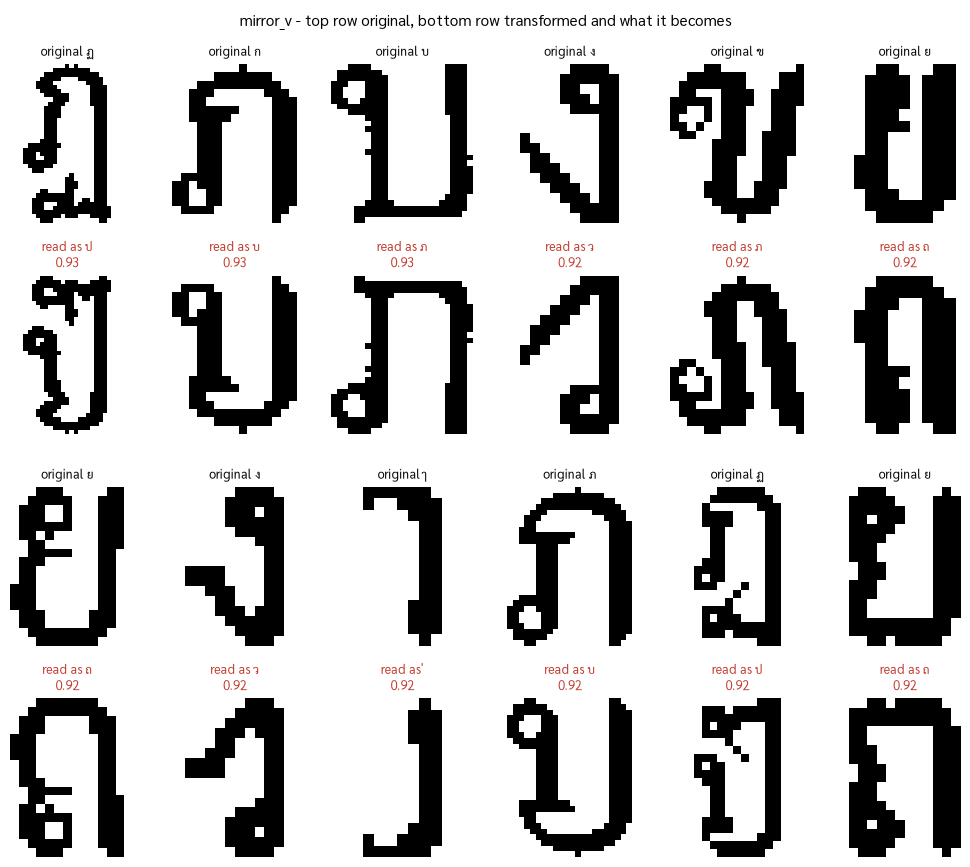

In [8]:
# See a flip turn one character into another.
#   show_flip("mirror_v")   show_flip("mirror_h")   show_flip("rot180")   show_flip("rot90_cw")
def show_flip(transform, n=12):
    fn = SS.FAMILY_C[transform]
    imgs = [fn(x) for x in _base_imgs]
    batches, keep = SS.to_batch(imgs, cfg, device)
    pr = SS.probs_for(model, batches)
    pred, conf, yk = pr.argmax(1), pr.max(1), _base_y[keep]
    changed = np.where(pred != yk)[0]
    conf_changed = changed[np.argsort(conf[changed])[::-1]][:n]
    print(f"{transform}: {len(keep)} images, mean confidence {conf.mean():.3f}, "
          f"{(pred == yk).mean():.1%} still read as the original class")
    cols = min(n, 6); rows = int(np.ceil(len(conf_changed) / cols))
    fig, ax = plt.subplots(rows * 2, cols, figsize=(1.7 * cols, 2.2 * rows * 2), squeeze=False)
    for axx in np.ravel(ax): axx.axis("off")
    for j, i in enumerate(conf_changed):
        r, c = divmod(j, cols)
        ax[r * 2][c].imshow(_base_imgs[keep[i]], cmap="gray", vmin=0, vmax=255)
        ax[r * 2][c].set_title(f"original {code_to_char(CLASS_CODES[yk[i]])}", fontsize=9)
        ax[r * 2 + 1][c].imshow(imgs[keep[i]], cmap="gray", vmin=0, vmax=255)
        ax[r * 2 + 1][c].set_title(f"read as {code_to_char(CLASS_CODES[pred[i]])}" + chr(10)
                                   + f"{conf[i]:.2f}", fontsize=9, color="#c0392b")
    fig.suptitle(f"{transform} - top row original, bottom row transformed and what it becomes",
                 fontsize=11)
    fig.tight_layout(); plt.show()

show_flip("mirror_v")

## 6. Picking a confidence threshold

Family B showed a threshold is enough to filter invalid input. This is where the number gets chosen: what each threshold costs on real glyphs against how much junk still leaks through.

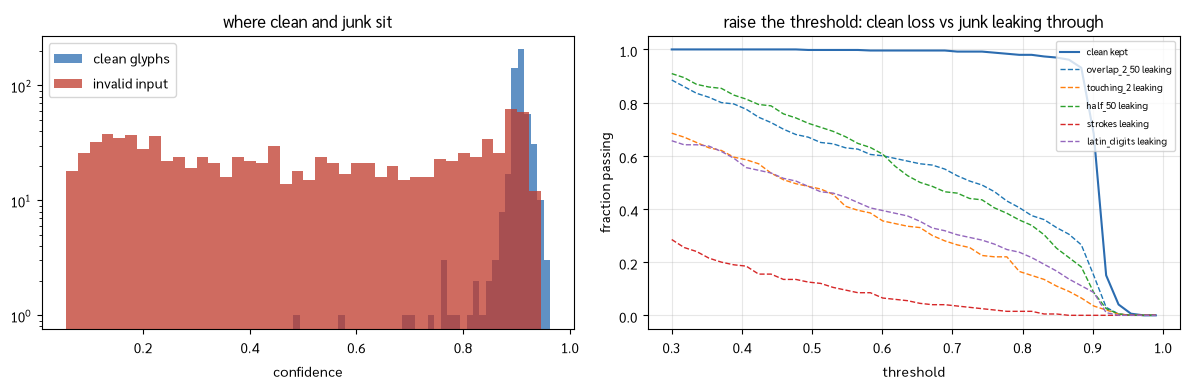

 threshold   clean kept   clean acc kept   worst junk leaking
      0.50       99.8%          0.9857               71.7%
      0.70       99.4%          0.9857               53.5%
      0.80       98.0%          0.9876               39.0%
      0.90       74.8%          0.9918               16.0%
      0.95        0.6%          1.0000                0.0%


In [9]:
# Choosing a confidence threshold: what it keeps on real glyphs vs what it rejects on junk.
# Family B showed a threshold is enough to filter invalid input - this is where you pick the number.
_clean_batches, _clean_keep = SS.to_batch(_base_imgs, cfg, device)
_clean_pr = SS.probs_for(model, _clean_batches)
_clean_conf = _clean_pr.max(1)
_clean_ok = _clean_pr.argmax(1) == _base_y[_clean_keep]

JUNK_KINDS = ["overlap_2_50", "touching_2", "half_50", "strokes", "latin_digits"]
_junk_conf = {}
for k in JUNK_KINDS:
    ims = _build_junk(k, 200)
    bt, kp = SS.to_batch(ims, cfg, device)
    _junk_conf[k] = SS.probs_for(model, bt).max(1)

taus = np.linspace(0.3, 0.99, 40)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(_clean_conf, bins=40, alpha=0.75, label="clean glyphs", color="#2b6cb0")
axes[0].hist(np.concatenate(list(_junk_conf.values())), bins=40, alpha=0.75,
             label="invalid input", color="#c0392b")
axes[0].set_yscale("log"); axes[0].set_xlabel("confidence"); axes[0].legend()
axes[0].set_title("where clean and junk sit")

axes[1].plot(taus, [(_clean_conf >= t).mean() for t in taus], label="clean kept", color="#2b6cb0")
for k, v in _junk_conf.items():
    axes[1].plot(taus, [(v >= t).mean() for t in taus], ls="--", lw=1, label=f"{k} leaking")
axes[1].set_xlabel("threshold"); axes[1].set_ylabel("fraction passing")
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
axes[1].set_title("raise the threshold: clean loss vs junk leaking through")
fig.tight_layout(); plt.show()

print(f"{'threshold':>10} {'clean kept':>12} {'clean acc kept':>16} {'worst junk leaking':>20}")
for t in (0.5, 0.7, 0.8, 0.9, 0.95):
    kept = _clean_conf >= t
    leak = max((v >= t).mean() for v in _junk_conf.values())
    acc = _clean_ok[kept].mean() if kept.any() else float("nan")
    print(f"{t:>10.2f} {kept.mean():>11.1%} {acc:>15.4f} {leak:>19.1%}")

## 7. Run the same checks on your own images

Point `MY_DIR` at a folder and re-run. This is the same code path as the on-the-day tool `scripts/evaluate_folder.py`.

In [10]:
# Run the same checks on YOUR OWN images.
# Point MY_DIR at a folder of glyph images and re-run this cell. Files whose name contains the
# TIS-620 code (e.g. 161ka.png) or a Thai character get scored; the rest are predictions only.
MY_DIR = PROJECT_DIR / "example"

if not Path(MY_DIR).exists():
    print(f"{MY_DIR} does not exist - set MY_DIR to a folder of images and re-run this cell.")
    print("The on-the-day tool is the same code path:")
    print("   uv run --no-sync python scripts/evaluate_folder.py --dir <folder>")
else:
    import subprocess
    cmd = [sys.executable, "scripts/evaluate_folder.py", "--dir", str(MY_DIR),
           "--ckpt", CKPT, "--out-dir", "outputs/onsite_nb"]
    print(" ".join(cmd)); print()
    print(subprocess.run(cmd, capture_output=True, text=True).stdout[-4000:])

/home/metaverse/work/thaichar72/example does not exist - set MY_DIR to a folder of images and re-run this cell.
The on-the-day tool is the same code path:
   uv run --no-sync python scripts/evaluate_folder.py --dir <folder>
